In [1]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_causal_structures():
    """
    Generate and plot three causal graph structures with improved layout:
    1. Confounder (X->Z<-Y)
    2. Mediator (X->Z->Y)
    3. Collider (X<-Z->Y)
    Save each plot as a separate PNG file
    """
    # Set up common parameters
    plt.rcParams['figure.figsize'] = (5, 4)
    plt.rcParams['figure.autolayout'] = True
    plt.rcParams['figure.dpi'] = 300

    # 1. Confounder Structure (X->Z<-Y)
    plt.figure()
    G1 = nx.DiGraph()
    G1.add_edges_from([('X', 'Z'), ('Y', 'Z')])
    pos1 = {'X': (0, 0), 'Y': (2, 0), 'Z': (1, 1)}
    nx.draw(G1, pos1, with_labels=True, node_color='lightblue', 
            node_size=3500, arrowsize=20, font_size=30, font_weight='bold')
    #plt.title('Collider')
    plt.axis('equal')
    plt.savefig('collider.pdf', bbox_inches='tight', pad_inches=0.1)
    plt.close()
    
    # 2. Mediator Structure (X->Z->Y)
    plt.figure()
    G2 = nx.DiGraph()
    G2.add_edges_from([('X', 'Z'), ('Z', 'Y')])
    pos2 = {'X': (0, 0), 'Y': (2, 0), 'Z': (1, 1)}
    nx.draw(G2, pos2, with_labels=True, node_color='lightblue', 
            node_size=3500, arrowsize=20, font_size=30, font_weight='bold')
    #plt.title('Mediator')
    plt.axis('equal')
    plt.savefig('mediator.pdf', bbox_inches='tight', pad_inches=0.1)
    plt.close()
    
    # 3. Collider Structure (X<-Z->Y)
    plt.figure()
    G3 = nx.DiGraph()
    G3.add_edges_from([('Z', 'X'), ('Z', 'Y')])
    pos3 = {'X': (0, 0), 'Y': (2, 0), 'Z': (1, 1)}
    nx.draw(G3, pos3, with_labels=True, node_color='lightblue', 
            node_size=3500, arrowsize=20, font_size=30, font_weight='bold')
    #plt.title('Confounder')
    plt.axis('equal')
    plt.savefig('confounder.pdf', bbox_inches='tight', pad_inches=0.1)
    plt.close()
def plot_example():
    import matplotlib.pyplot as plt
    import networkx as nx
    import matplotlib.patches as mpatches
    
    # 1. Setup
    plt.figure(figsize=(7, 5))
    G1 = nx.DiGraph()
    G1.add_edges_from([('T_air', 'Reco'), ('Rg', 'Reco'), ('Rg','T_air')])
    
    # Position nodes closer together
    pos1 = {'T_air': (0, 0), 'Reco': (1, 0), 'Rg': (0.5, 0.7)}
    
    # Create a list of node colors where T_air has a different color
    node_colors = ['#d5f5e3' if node == 'T_air' else 'lightblue' for node in G1.nodes()]
    
    # Draw the network without labels first - increase node_size
    nx.draw(G1, pos1, with_labels=False, node_color=node_colors, 
            node_size=8000, arrowsize=20, arrows=True, 
            connectionstyle='arc3,rad=0.1')  # Adding curved edges
    
    # Add labels separately to allow multiline text
    for node, (x, y) in pos1.items():
        if node == 'T_air':
            # Multiline label for T_air
            plt.text(x, y, 'T$_{air}$', horizontalalignment='center',
                    verticalalignment='center', fontsize=30, fontweight='bold')
        else:
            plt.text(x, y, node, horizontalalignment='center',
                    verticalalignment='center', fontsize=30, fontweight='bold')
    
    plt.axis('equal')
    plt.savefig('respi.pdf', bbox_inches='tight', pad_inches=0.1)
    plt.close()
    
    # 2. Intervention
    plt.figure(figsize=(7, 5))
    G2 = nx.DiGraph()
    G2.add_edges_from([('do_T_air', 'Reco'), ('Rg', 'Reco')])
    
    # Position nodes closer together
    pos2 = {'do_T_air': (0, 0), 'Reco': (1.2, 0), 'Rg': (0.6, 0.7)}
    
    # Create a list of node colors where T_air has a different color
    node_colors = ['#d5f5e3' if node == 'do_T_air' else 'lightblue' for node in G2.nodes()]
    
    # Draw the network without labels first - increase node_size
    nx.draw(G2, pos2, with_labels=False, node_color=node_colors, 
            node_size=10000, arrowsize=20, arrows=True)
    
    # Add labels separately to allow multiline text
    for node, (x, y) in pos2.items():
        if node == 'do_T_air':
            # Label with do() operator
            plt.text(x, y, 'do(T$_{air}$=t)', horizontalalignment='center',
                    verticalalignment='center', fontsize=30, fontweight='bold')
        else:
            plt.text(x, y, node, horizontalalignment='center',
                    verticalalignment='center', fontsize=30, fontweight='bold')
    
    plt.axis('equal')
    plt.savefig('intervention.pdf', bbox_inches='tight', pad_inches=0.1)
    plt.close()

# Call the function to generate and save the plots
plot_example()

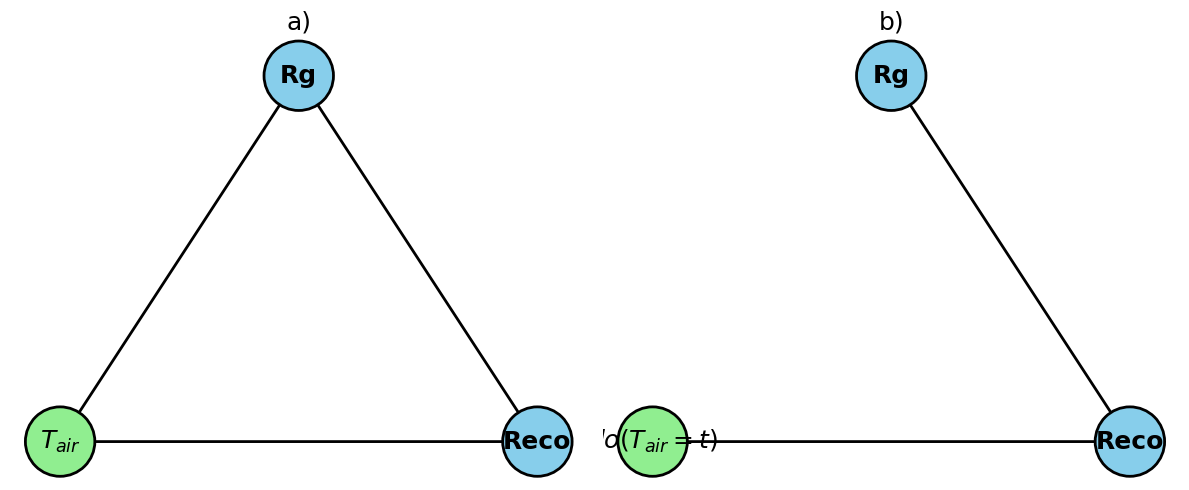

In [2]:
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.patches as mpatches
import numpy as np

# Create the observational setting diagram
plt.figure(figsize=(6, 5))
G1 = nx.DiGraph()

# Add nodes
nodes = ["Rg", "$T_{air}$", "Reco"]  # Using LaTeX for subscript
G1.add_nodes_from(nodes)

# Add edges
G1.add_edges_from([("Rg", "$T_{air}$"), ("Rg", "Reco"), ("$T_{air}$", "Reco")])

# Define more compact node positions
pos1 = {"Rg": (0.5, 0.8), "$T_{air}$": (0.1, 0.2), "Reco": (0.9, 0.2)}

# Node colors
node_colors1 = ['skyblue', 'lightgreen', 'skyblue']

# Draw nodes with increased size
nx.draw_networkx_nodes(G1, pos1, node_size=2500, node_color=node_colors1, edgecolors='black', linewidths=2)

# Draw edges with arrow size proportional to node size
nx.draw_networkx_edges(G1, pos1, arrows=True, arrowsize=25, width=2, edge_color='black')

# Draw labels with larger font
nx.draw_networkx_labels(G1, pos1, font_size=18, font_weight='bold')

plt.axis('off')
plt.tight_layout()
plt.savefig('observational_setting.png', dpi=300, bbox_inches='tight')
plt.close()

# Create the intervention setting diagram
plt.figure(figsize=(6, 5))
G2 = nx.DiGraph()

# Add nodes - using do-operator
nodes2 = ["Rg", "$do(T_{air}=t)$", "Reco"]
G2.add_nodes_from(nodes2)

# Add edges - no edge from Rg to Tair due to intervention
G2.add_edges_from([("Rg", "Reco"), ("$do(T_{air}=t)$", "Reco")])

# Same positions as before
pos2 = {"Rg": (0.5, 0.8), "$do(T_{air}=t)$": (0.1, 0.2), "Reco": (0.9, 0.2)}

# Node colors
node_colors2 = ['skyblue', 'lightgreen', 'skyblue']

# Draw nodes
nx.draw_networkx_nodes(G2, pos2, node_size=2500, node_color=node_colors2, edgecolors='black', linewidths=2)

# Draw edges
nx.draw_networkx_edges(G2, pos2, arrows=True, arrowsize=25, width=2, edge_color='black')

# Draw labels with larger font
nx.draw_networkx_labels(G2, pos2, font_size=18, font_weight='bold')

plt.axis('off')
plt.tight_layout()
plt.savefig('intervention_setting.png', dpi=300, bbox_inches='tight')
plt.close()

# Create combined figure with both settings
plt.figure(figsize=(12, 5))

# First subplot - Observational
ax1 = plt.subplot(121)
nx.draw_networkx_nodes(G1, pos1, ax=ax1, node_size=2500, node_color=node_colors1, edgecolors='black', linewidths=2)
nx.draw_networkx_edges(G1, pos1, ax=ax1, arrows=True, arrowsize=25, width=2, edge_color='black')
nx.draw_networkx_labels(G1, pos1, ax=ax1, font_size=18, font_weight='bold')
ax1.set_title('a)', fontsize=18)
ax1.axis('off')

# Second subplot - Intervention
ax2 = plt.subplot(122)
nx.draw_networkx_nodes(G2, pos2, ax=ax2, node_size=2500, node_color=node_colors2, edgecolors='black', linewidths=2)
nx.draw_networkx_edges(G2, pos2, ax=ax2, arrows=True, arrowsize=25, width=2, edge_color='black')
nx.draw_networkx_labels(G2, pos2, ax=ax2, font_size=18, font_weight='bold')
ax2.set_title('b)', fontsize=18)
ax2.axis('off')

plt.tight_layout()
plt.savefig('causal_diagrams.png', dpi=300, bbox_inches='tight')
plt.show()